## Reinforcement Learning (Bandits for recomendators)

#### Starting for simulated data

In [7]:

import pandas as pd
import numpy as np

dfcb = pd.read_excel('../data/sim1.xlsx')
print("Columnas cargadas:", dfcb.columns.tolist())

dfcb = dfcb.rename(columns={
    'gender': 'female',
    'current_exercise': 'c_exer',
    'Pregunta_1': 'ext_mot',
    'Pregunta_2': 'aut_mot',
    'Pregunta_3': 'attitude',
    'Pregunta_4': 'sub_norm',
    'Pregunta_5': 'beh_cont',
    'Pregunta_6': 'intent',
    'Pregunta_7': 'autonomy',
    'action': 'group',
    'score': 'bcont'
})

Columnas cargadas: ['random', 'female', 'income', 'c_exer', 'ext_mot', 'aut_mot', 'attitude', 'sub_norm', 'beh_cont', 'intent', 'autonomy', 'group', 'bcont', 'prob', 'behavior']


In [8]:
import vowpalwabbit
import random
import matplotlib.pyplot as plt
import pandas as pd
import itertools
import numpy as np
import seaborn as sns
import statsmodels.formula.api as smf

In [9]:
dfcb['behavior'] = -dfcb['behavior']
dfcb.describe()

,random,female,income,c_exer,ext_mot,aut_mot,attitude,sub_norm,beh_cont,intent,autonomy,group,bcont,prob,behavior
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.00,2000.000000
mean,1000.500000,0.482500,1.832500,2.416000,1.905500,3.849500,4.998500,4.099500,5.106000,4.49050,4.366000,2.001000,60.750815,0.33,0.499500
std,577.494589,0.499819,0.822668,0.851062,0.471891,0.949368,1.341789,1.504238,1.300234,1.59191,1.167787,0.816904,18.804042,0.00,0.500125
min,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,9.550000,0.33,0.000000
25%,500.750000,0.000000,1.000000,2.000000,2.000000,3.000000,4.000000,3.000000,4.000000,3.00000,4.000000,1.000000,47.710000,0.33,0.000000
50%,1000.500000,0.000000,2.000000,2.000000,2.000000,4.000000,5.000000,4.000000,5.000000,5.00000,4.000000,2.000000,59.950000,0.33,0.000000
75%,1500.250000,1.000000,3.000000,3.000000,2.000000,5.000000,6.000000,5.000000,6.000000,6.00000,5.000000,3.000000,73.262500,0.33,1.000000
max,2000.000000,1.000000,3.000000,5.000000,4.000000,5.000000,7.000000,7.000000,7.000000,7.00000,7.000000,3.000000,129.200000,0.33,1.000000


In [10]:
pd.pivot_table(dfcb, values='behavior', columns=['group'], aggfunc='mean')

group,1,2,3
behavior,0.540541,0.522523,0.435629


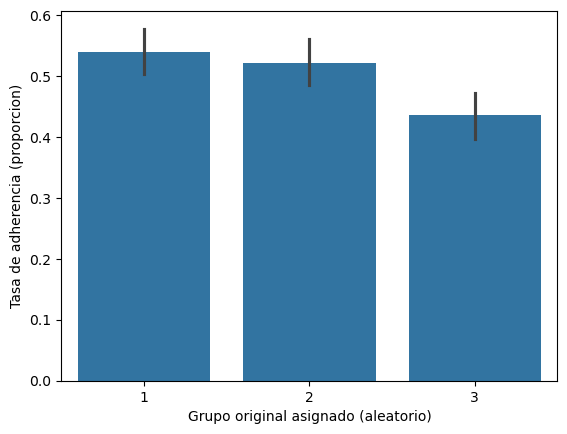

In [11]:
ax = sns.barplot(data = dfcb, x='group', y='behavior')

# Set title and labels
ax.set_xlabel('Grupo original asignado (aleatorio)')
ax.set_ylabel('Tasa de adherencia (proporcion)')

# Show the plot
plt.show()

#### PARSING AND OTHER FUNCTIONS

In [12]:
reg = smf.logit(formula="""
behavior ~ c_exer + ext_mot + aut_mot + beh_cont + attitude + sub_norm
+ C(female) + C(income) + C(group) + intent + autonomy
""", data=dfcb).fit()

print(reg.summary())


Optimization terminated successfully.
         Current function value: 0.069160
         Iterations 12
                           Logit Regression Results                           
Dep. Variable:               behavior   No. Observations:                 2000
Model:                          Logit   Df Residuals:                     1986
Method:                           MLE   Df Model:                           13
Date:                Tue, 17 Jun 2025   Pseudo R-squ.:                  0.9002
Time:                        08:57:41   Log-Likelihood:                -138.32
converged:                       True   LL-Null:                       -1386.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        -86.5904      7.856    -11.022      0.000    -101.988     -71.192
C(female)[T.1]  

#### OFFLINE POLICY

In [13]:
with open("sim1.vw", "w") as vwfile:
    for _, row in dfcb.iterrows():
        action = int(row["group"])       
        cost = 1 - float(row["behavior"])    
        prob = 0.33                     

        features = (
            f"c_exer:{row['c_exer']} "
            f"aut_mot:{row['aut_mot']} "
            f"beh_cont:{row['beh_cont']} "
            f"attitude:{row['attitude']} "
            f"sub_norm:{row['sub_norm']} "
            f"income:{row['income']} "
            f"intent:{row['intent']} "
            f"autonomy:{row['autonomy']}"
        )

        vwfile.write(f"{action}:{cost}:{prob} | {features}\n")



In [14]:

from vowpalwabbit import pyvw
vw = pyvw.Workspace('--cb 3 --cb_type dr')
with open("sim1.vw", "r") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        ex = vw.example(line)
        vw.learn(ex)

vw.save('cb_model.vw')

vw.finish()

In [15]:
vw = pyvw.Workspace('--cb 3 -i cb_model.vw -t')

logged_actions = []
predicted_actions = []

with open("sim1.vw", "r") as f:
    for line in f:
        ex = vw.example(line.strip())
        pred = vw.predict(ex)
        predicted_actions.append(pred)

        logged_action = int(line.split(":")[0])
        logged_actions.append(logged_action)

vw.finish()

In [16]:
df = pd.DataFrame({'random': logged_actions, 'optimal': predicted_actions, 'behavior' : dfcb['behavior']})
dfcb['optimal'] = df['optimal']
df.pivot_table(index='optimal', values='behavior', aggfunc='mean', fill_value=0)

,behavior
optimal,
1,0.412231
2,0.710875
3,0.272727


<Axes: xlabel='random', ylabel='optimal'>

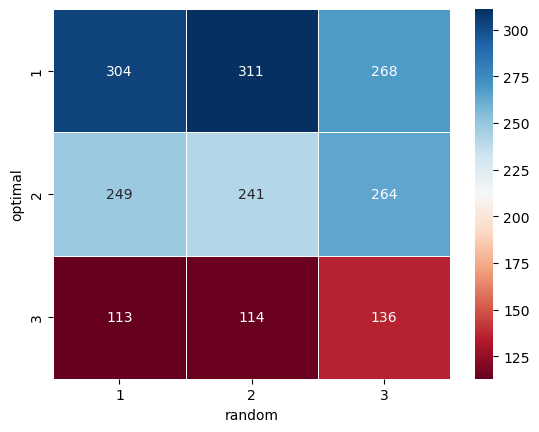

In [17]:
dfs = df.pivot_table(index='optimal', columns='random', aggfunc='size', fill_value=0)
sns.heatmap(dfs, annot=True, cmap='RdBu', linewidths=.5, fmt='.0f', cbar=True)

In [ ]:
# ======= VARIABLES USADAS =======
p1 = dfcb['ext_mot']
p2 = dfcb['aut_mot']
p3 = dfcb['attitude']
p4 = dfcb['sub_norm']
p5 = dfcb['beh_cont']
p6 = dfcb['intent']
p7 = dfcb['autonomy']
gender = dfcb['female']
income = dfcb['income']
exercise = dfcb['c_exer']
action = dfcb['optimal']

# ======= CÁLCULO DEL SCORE  ======= 
base_part = (
    p1 * -0.1 + p2 * 0.6 + p3 * 1.0 + p4 * 0.4 + p5 * 1.1 + p6 * 2.6 + p7 * 0.6
)
multiplicative_part = (
  1 + 0.2 * income - 1.1 * action + 0.3 * exercise * action + 0.2 * gender - 0.2 * (3 - action)
)
additional_bonus = 0.2 * income * action + 0.1 * exercise + (3 - action) * (p6 + p7) * 0.5 + 0.1 * action*action * (p6 + p7)

score = base_part + base_part * multiplicative_part + additional_bonus

df['score_op'] = score
threshold_1 = df['score_op'].quantile(0.5) 
threshold_2 = df['score_op'].quantile(0.5)
threshold_3 = df['score_op'].quantile(0.5)

# ======= BEHAVIOR =======
thresholds = np.select(
    [action == 1, action == 2, action == 3],
    [50, 50 , 50], 
    default=40
)

df['score_op'] = dfcb['bcont']
df['behavior_op'] = (score >= thresholds).astype(int)
df.describe()

,random,optimal,behavior,score_op,behavior_op
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2.001000,1.740000,0.499500,60.750815,0.597500
std,0.816904,0.745438,0.500125,18.804042,0.490524
min,1.000000,1.000000,0.000000,9.550000,0.000000
25%,1.000000,1.000000,0.000000,47.710000,0.000000
50%,2.000000,2.000000,0.000000,59.950000,1.000000
75%,3.000000,2.000000,1.000000,73.262500,1.000000
max,3.000000,3.000000,1.000000,129.200000,1.000000


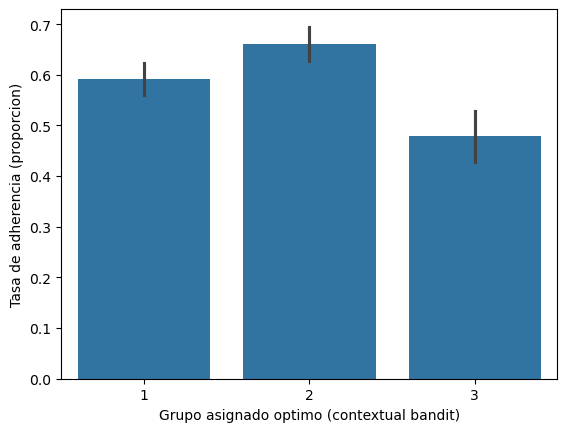

In [25]:
ax = sns.barplot(data = df, x='optimal', y='behavior_op')

# Set title and labels
ax.set_xlabel('Grupo asignado optimo (contextual bandit)')
ax.set_ylabel('Tasa de adherencia (proporcion)')

# Show the plot
plt.show()

#### Bonus track: SEM model from simulated data

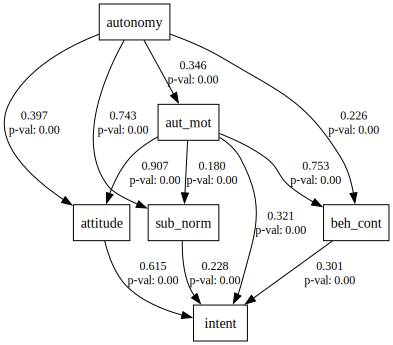

In [1082]:
import semopy
mod = """
# Structural model
intent ~ aut_mot + beh_cont + sub_norm + attitude
sub_norm ~ aut_mot + autonomy 
beh_cont ~ aut_mot + autonomy 
attitude ~ aut_mot + autonomy
aut_mot ~ autonomy
    """

model = semopy.Model(mod)
out=model.fit(dfcb)
#print(out)
#print(model.inspect())
semopy.semplot(model, "semmodel.png")